# 2.5D slab depth ablation — PSNR vs CR

Sweep the slab depth **K ∈ {3, 5, 7, 9, 11}** and compare against the **2D** residual model
and the **NeurLZ** baseline, on three datasets:

| Dataset | Time budget | Params | Fields |
|---|---|---|---|
| WarpX `(2048,256,256)` | 40 s | 30k | single |
| Hurricane CLOUD `(100,500,500)` | 80 s | 6k | + 6 aux |
| Magnetic Reconnection `(512,512,512)` | 40 s | 30k | single |

All BG models (2D and every slab-K) **slice / stack along axis 0** and train on full in-plane
planes with the **same recipe** (lr, bands, seed) **and the same wall-clock budget** (`max_train_time`, epochs
uncapped) — so among the BG curves the only difference is the slab depth K (2D ≡ "K=1"), trained
for the identical amount of time. NeurLZ is single-field (its own design) and trained for the **same wall-clock budget**. CR charges `SZ3 bytes + (model params × 2 bytes, bf16)`; aux fields are not charged.

In [1]:
import os, sys, time, subprocess
import numpy as np
import matplotlib.pyplot as plt
import torch

SPERR_BIN    = "/home/sam/Halo_Finder/SPERR/build/bin/sperr3d"
SZ3_LIB      = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
PYSZ_PATH    = "/home/sam/Data_Compression/SZ3/tools/pysz"
SCRIPTS_PATH = "/home/sam/Halo_Finder/Final_design/base_script"
for p in (PYSZ_PATH, SCRIPTS_PATH):
    if p not in sys.path:
        sys.path.append(p)

import importlib, bg_stage
importlib.reload(bg_stage)
from pysz import SZ
from bg_stage import train_bg_only, run_bg_inference, unwrap_bg_model
from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_shard import pick_bg_h_under_budget

device    = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sz_engine = SZ(SZ3_LIB)
BYTES_PER_PARAM = 2          # model weights stored as bf16
SEED = 17   # shared seed: NeurLZ + BG pipeline use the same SEED
import random as _random
def set_seed(s=SEED):
    torch.manual_seed(s); np.random.seed(s); _random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
DETERMINISTIC = False   # True = bit-exact reproducible (cuDNN deterministic convs, ~3-4x slower); seed is fixed either way
torch.backends.cudnn.benchmark = not DETERMINISTIC; torch.backends.cudnn.deterministic = DETERMINISTIC
set_seed(SEED)

def compute_psnr(x_true, x_hat, drange):
    mse = float(np.mean((np.asarray(x_true, np.float64) - np.asarray(x_hat, np.float64)) ** 2))
    return 100.0 if mse == 0 else 20.0 * np.log10(drange) - 10.0 * np.log10(mse)

def bg_h_for_params(budget, shape, n_fields):
    """Largest bg_h whose split-bands model fits the param budget."""
    h, est = pick_bg_h_under_budget(int(budget), shape=shape, n_fields=int(n_fields),
                                    bg_arch="spatial", h_candidates=list(range(3, 256)))
    return int(h)

def run_sperr(data_file, target_gt, shape, drange, target_psnr):
    """SPERR at a target PSNR.  Returns (CR, PSNR, recon, nbytes): the decompressed
    volume (for the SPERR+model curve) and the bitstream size.  PSNR is recomputed."""
    W, H, D = shape[2], shape[1], shape[0]          # SPERR wants fastest-varying first
    tag = np.random.randint(1 << 30)
    bit = f"/tmp/sperr_{tag}.bit"; rec = f"/tmp/sperr_{tag}.dec.f32"
    subprocess.run([SPERR_BIN, "-c", "--ftype", "32",
                    "--dims", str(W), str(H), str(D), "--psnr", f"{float(target_psnr):.4f}",
                    "--bitstream", bit, data_file], capture_output=True, text=True)
    if not os.path.exists(bit):
        return None, None, None, None
    nbytes = os.path.getsize(bit)
    subprocess.run([SPERR_BIN, "-d", "--decomp_f", rec, bit], capture_output=True, text=True)
    cr = psnr = recon = None
    if os.path.exists(rec):
        recon = np.fromfile(rec, dtype=np.float32).reshape(shape)
        psnr  = compute_psnr(target_gt, recon, drange)
        cr    = (int(np.prod(shape)) * 4) / nbytes
    for f in (bit, rec):
        if os.path.exists(f):
            os.remove(f)
    return cr, psnr, recon, nbytes

print("Setup ready | device:", device)

Setup ready | device: cuda:0


In [2]:
# ── NeurLZ baseline (SZ3 + monai BasicUNet error predictor) ──────────────────
# Faithful re-impl of neurlz/train.py's recipe (per-slice BasicUNet predicts the
# minmax-normalized SZ3 error; L1, Adam 1e-2, cosine T_max=1500); enhanced output
# clamped to the rel error bound (same as the SZ3+model pipeline).
import io, contextlib, random, time
from monai.networks.nets import BasicUNet
from config_io import _error_bounded_post_process

ADD_NEURLZ        = True
NEURLZ_LR         = 1e-2
NEURLZ_BATCH      = 10
NEURLZ_MAX_PIXELS_PER_BATCH = 1024 * 1024   # cap batch*H*W so big slices don't OOM
NEURLZ_VERBOSE    = True     # print per-epoch loss + PSNR
NEURLZ_EVAL_EVERY = 1        # compute PSNR every K epochs (loss prints every epoch)
NEURLZ_EPOCH_MULT = 1
NEURLZ_POSTPROCESS = False   # error-bound clamp on NeurLZ output; OFF = raw model output
# BasicUNet channel widths (6-tuple). "match" auto-sizes a uniform (w,)*6 so its
# param count ~= your BG model's -> iso-parameter / iso-CR comparison on the plot.
# Or give an explicit tuple, e.g. (4,4,4,4,4,4) for NeurLZ's default (~3k params).
NEURLZ_FEATURES   = (4,4,4,4,4,4) # “match"
NEURLZ_SINGLE_FIELD = True   # NeurLZ is a single-field method; aux channels swamp the tiny net -> ignore them

def _basicunet_nparams(features, n_fields):
    with contextlib.redirect_stdout(io.StringIO()):
        m = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                      in_channels=int(n_fields), out_channels=1)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad); del m
    return n

def _neurlz_features_for_params(target_params, n_fields, lo=4, hi=384):
    """Uniform width (w,)*6 BasicUNet whose param count is closest to target_params."""
    a, b, best = lo, hi, lo
    while a <= b:
        mid = (a + b) // 2
        if _basicunet_nparams((mid,) * 6, n_fields) <= target_params:
            best = mid; a = mid + 1
        else:
            b = mid - 1
    w_hi = min(best + 1, hi)
    n_lo = _basicunet_nparams((best,) * 6, n_fields)
    n_hi = _basicunet_nparams((w_hi,) * 6, n_fields)
    w = best if abs(n_lo - target_params) <= abs(n_hi - target_params) else w_hi
    return (w,) * 6

def _mm(x, eps=1e-8):
    lo, hi = float(np.min(x)), float(np.max(x))
    return ((np.asarray(x, np.float32) - lo) / (hi - lo + eps)).astype(np.float32), (lo, hi)

def run_neurlz(target_gt, base_recon, aux_list, shape, drange, rel, epochs, features, time_budget=None, slice_axis=0, return_history=False):
    """SZ3 + NeurLZ on one base reconstruction. Returns (psnr, n_params)."""
    if NEURLZ_SINGLE_FIELD:
        aux_list = []                                    # faithful NeurLZ: target field only (in_channels=1)
    if int(slice_axis) != 0:                              # train on the BG-chosen slicing axis (fair iso-orientation)
        _p = {1: (1, 0, 2), 2: (2, 0, 1)}[int(slice_axis)]
        target_gt  = np.ascontiguousarray(np.transpose(np.asarray(target_gt, np.float32), _p))
        base_recon = np.ascontiguousarray(np.transpose(np.asarray(base_recon, np.float32), _p))
        aux_list   = [np.ascontiguousarray(np.transpose(np.asarray(a, np.float32), _p)) for a in aux_list]
        shape = target_gt.shape
    D, H, W = shape
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    eff_batch = max(1, min(NEURLZ_BATCH, NEURLZ_MAX_PIXELS_PER_BATCH // (H * W)))
    if eff_batch < NEURLZ_BATCH:
        print(f"           [neurlz] slice {H}x{W}: batch {NEURLZ_BATCH} -> {eff_batch} (memory)")
    tgt = np.asarray(target_gt, np.float32)
    lq  = np.ascontiguousarray(base_recon, np.float32)
    fields = [lq] + [np.asarray(a, np.float32) for a in aux_list]
    n_fields = len(fields)
    lq_n = np.stack([_mm(f)[0] for f in fields], axis=1)
    err_n, (e_lo, e_hi) = _mm(tgt - lq)
    ph, pw = (-H) % 16, (-W) % 16
    pad = ((0, 0), (0, 0), (0, ph), (0, pw))
    Xlq  = torch.from_numpy(np.pad(lq_n, pad, mode="reflect"))
    Yerr = torch.from_numpy(np.pad(err_n[:, None], pad, mode="reflect"))

    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    with contextlib.redirect_stdout(io.StringIO()):
        model = BasicUNet(spatial_dims=2, features=tuple(features), act="gelu",
                          in_channels=n_fields, out_channels=1).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    opt   = torch.optim.Adam(model.parameters(), lr=NEURLZ_LR)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=1500)
    mse    = torch.nn.MSELoss()
    idx = np.arange(D)
    def _enhanced():
        model.eval()
        out = lq.copy()
        with torch.no_grad():
            for st in range(0, D, eff_batch):
                bi = list(range(st, min(st + eff_batch, D)))
                pred = model(Xlq[bi].to(device)).cpu().numpy()[:, 0, :H, :W]
                out[bi] = lq[bi] + (pred * (e_hi - e_lo + 1e-8) + e_lo)
        model.train()
        if NEURLZ_POSTPROCESS:
            return _error_bounded_post_process(x_enhanced=out, x_prime=lq, absolute_error_bound=0.0,
                                               relative_error_bound=float(rel), verbose=False, a=1.0)
        return out

    # Train under a wall-clock TIME BUDGET (= the BG model's pure 20-epoch time) when
    # `time_budget` is given; else fall back to a fixed `epochs` count. Only the
    # train steps are timed -- the per-epoch PSNR eval is excluded (matches the BG
    # model's hist["time"], which also excludes eval).
    use_budget = time_budget is not None and float(time_budget) > 0
    ep_cap     = 100000 if use_budget else int(epochs)
    budget_str = f"{float(time_budget):.1f}s" if use_budget else f"{int(epochs)}ep"
    train_time, ep = 0.0, 0
    hist_t, hist_p = [], []
    model.train()
    while ep < ep_cap:
        np.random.shuffle(idx)
        tot, nb = 0.0, 0
        t_ep = time.perf_counter()
        for st in range(0, D, eff_batch):
            bi = idx[st:st + eff_batch]
            loss = mse(model(Xlq[bi].to(device)), Yerr[bi].to(device))
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            sched.step()
            tot += float(loss.item())
            nb += 1
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        train_time += time.perf_counter() - t_ep      # pure train time (eval excluded)
        ep += 1
        done = use_budget and train_time >= float(time_budget)
        eval_now = (ep % NEURLZ_EVAL_EVERY == 0) or done or (not use_budget and ep == int(epochs))
        if eval_now and (NEURLZ_VERBOSE or return_history):
            pe = compute_psnr(tgt, _enhanced(), drange)
            if return_history:
                hist_t.append(float(train_time)); hist_p.append(float(pe))
            if NEURLZ_VERBOSE:
                print(f"           [neurlz] ep {ep:3d} | {train_time:5.1f}/{budget_str} | MSE {tot/max(nb,1):.6f} | PSNR {pe:.2f} dB")
        elif NEURLZ_VERBOSE:
            print(f"           [neurlz] ep {ep:3d} | {train_time:5.1f}/{budget_str} | MSE {tot/max(nb,1):.6f}")
        if done:
            break

    enh = _enhanced()
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    if return_history:
        return compute_psnr(tgt, enh, drange), int(n_params), float(train_time), int(ep), {"time": hist_t, "psnr": hist_p}, enh
    return compute_psnr(tgt, enh, drange), int(n_params), float(train_time), int(ep)

print("run_neurlz ready | ADD_NEURLZ =", ADD_NEURLZ, "| NEURLZ_FEATURES =", NEURLZ_FEATURES)


/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_neurlz ready | ADD_NEURLZ = True | NEURLZ_FEATURES = (4, 4, 4, 4, 4, 4)


In [3]:
# ── slab-depth ablation: train a 2D (spatial) or 2.5D (slab2d, K) residual model ──
# Both archs slice/stack along axis 0, full in-plane planes, identical recipe -> only K differs.
SLAB_K_LIST          = [3, 5, 7, 9, 11]
SLAB_AXIS            = 0      # 2D slices and slab stacks along this axis (fair same-orientation)
STEPS_PER_EPOCH      = 256
NEURLZ_EPOCHS_FALLBACK = 200 # used only if NeurLZ iso-time budget is disabled

def _train_model(target_gt, aux_list, base_recon, base_rel, shape, drange, bg_h, train_time, lr,
                 arch, slab_k=None, bg_low_w=0.2, bg_mid_w=0.5, bg_high_w=1.0):
    """Train one residual model on base_recon for a fixed WALL-CLOCK budget
    (train_time seconds; epochs uncapped). arch in {'spatial','slab2d'}.
    Returns (psnr, n_params, train_time)."""
    Xs  = [target_gt] + list(aux_list)
    Xps = [np.ascontiguousarray(base_recon, np.float32)] + list(aux_list)
    patch = int(min(shape[1], shape[2]))            # full in-plane plane (axis1 x axis2)
    cfg = build_bg_only_cfg(
        X_target=Xs[0], Xps=Xps, max_train_time=float(train_time), bg_h=bg_h, roi_h=4,
        epochs=100000, steps_per_epoch=STEPS_PER_EPOCH, bg_patch_size=patch, bg_batch=1, lr=float(lr),
        bg_freq_weight=0.5, bg_fft_phase_weight=0.5, bg_freq_warmup_epochs=1, bg_field_norm="zscore")
    cfg.bg_arch = arch
    if arch == "slab2d":
        cfg.bg_slab_k = int(slab_k)
    cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
    cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
    cfg.bg_low_weight = bg_low_w; cfg.bg_mid_weight = bg_mid_w; cfg.bg_high_weight = bg_high_w
    cfg.bg_cr_rel_err = float(base_rel); cfg.bg_gpu_sampling = True; cfg.seed = SEED
    cfg.bg_cudnn_benchmark = not DETERMINISTIC; cfg.bg_cudnn_deterministic = DETERMINISTIC
    set_seed(SEED)
    def ev(m, c=cfg, Xs=Xs, Xps=Xps, r=base_rel):
        return compute_psnr(Xs[0], run_bg_inference(m, Xs, Xps, c, float(r)), drange), 0.0
    model, hist = train_bg_only(Xs=Xs, Xps=Xps, device=device, cfg=cfg, evaluator=ev)
    p = compute_psnr(Xs[0], run_bg_inference(model, Xs, Xps, cfg, float(base_rel)), drange)
    n_params = sum(q.numel() for q in unwrap_bg_model(model).parameters() if q.requires_grad)
    t = float(hist["time"][-1]) if hist.get("time") else float("nan")
    del model
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    return float(p), int(n_params), t

def bench_slab_k(name, target_gt, aux_list, shape, rel_errs, param_budget, train_time,
                 lr=1e-3, bg_low_w=0.2, bg_mid_w=0.5, bg_high_w=1.0):
    target_gt = np.asarray(target_gt, np.float32)
    drange    = float(target_gt.max() - target_gt.min())
    n_fields  = 1 + len(aux_list)
    import io as _io, contextlib as _cl
    with _cl.redirect_stdout(_io.StringIO()):           # silence the bg_h budget-search param prints
        bg_h = bg_h_for_params(param_budget, shape, n_fields)
    orig_bytes = int(np.prod(shape)) * 4
    print(f"[{name}] budget {param_budget:,} -> bg_h={bg_h} | n_fields={n_fields} | "
          f"axis0(depth)={shape[0]} patch={min(shape[1],shape[2])} | drange={drange:.3g} | "
          f"ISO-TIME budget={train_time:.0f}s/model")
    sz3  = {"CR": [], "PSNR": []}
    pipe = {"CR": [], "PSNR": []}                  # 2D
    neurlz = {"CR": [], "PSNR": []}                # single-field baseline
    slab = {K: {"CR": [], "PSNR": []} for K in SLAB_K_LIST}
    for rel in rel_errs:
        b, _ = sz_engine.compress(target_gt, 1, 0, float(rel), 0)
        sz_len = len(b); xq = sz_engine.decompress(b, shape, np.float32)
        p_sz3 = compute_psnr(target_gt, xq, drange); cr_sz3 = orig_bytes / sz_len
        sz3["CR"].append(cr_sz3); sz3["PSNR"].append(p_sz3)
        # 2D (spatial)
        p2d, n2d, t2d = _train_model(target_gt, aux_list, xq, rel, shape, drange, bg_h, train_time, lr,
                                     "spatial", bg_low_w=bg_low_w, bg_mid_w=bg_mid_w, bg_high_w=bg_high_w)
        pipe["CR"].append(orig_bytes/(sz_len+n2d*BYTES_PER_PARAM)); pipe["PSNR"].append(p2d)
        print(f"  rel={rel:.0e} | SZ3 {cr_sz3:7.1f}x/{p_sz3:5.1f}dB | 2D {p2d:5.1f} (+{p2d-p_sz3:.1f}) [{n2d:,}p {t2d:.1f}s]")
        # NeurLZ (single-field; SAME wall-clock budget as the BG models)
        p_n, n_n, t_n, ep_n = run_neurlz(target_gt, xq, aux_list, shape, drange, rel,
                                         NEURLZ_EPOCHS_FALLBACK, NEURLZ_FEATURES,
                                         time_budget=float(train_time), slice_axis=SLAB_AXIS)
        neurlz["CR"].append(orig_bytes/(sz_len+n_n*BYTES_PER_PARAM)); neurlz["PSNR"].append(p_n)
        print(f"           NeurLZ {p_n:5.1f} (+{p_n-p_sz3:.1f}) [{n_n:,}p {t_n:.1f}s/{ep_n}ep]")
        # 2.5D slab K sweep
        for K in SLAB_K_LIST:
            pK, nK, tK = _train_model(target_gt, aux_list, xq, rel, shape, drange, bg_h, train_time, lr,
                                      "slab2d", slab_k=K, bg_low_w=bg_low_w, bg_mid_w=bg_mid_w, bg_high_w=bg_high_w)
            slab[K]["CR"].append(orig_bytes/(sz_len+nK*BYTES_PER_PARAM)); slab[K]["PSNR"].append(pK)
            print(f"           slab K={K:2d} {pK:5.1f} (+{pK-p_sz3:.1f}) [{nK:,}p {tK:.1f}s]")
    return dict(name=name, sz3=sz3, pipe=pipe, neurlz=neurlz, slab=slab, bg_h=bg_h)

def plot_slab_k(r, title):
    fig, ax = plt.subplots(figsize=(8.5, 6), dpi=130)
    ax.plot(r["sz3"]["CR"],  r["sz3"]["PSNR"],  "^--", color="tab:gray",   label="SZ3", zorder=1)
    ax.plot(r["pipe"]["CR"], r["pipe"]["PSNR"], "o-",  color="tab:orange", label="SZ3 + model 2D", lw=2, zorder=3)
    if r["neurlz"]["CR"]:
        ax.plot(r["neurlz"]["CR"], r["neurlz"]["PSNR"], "v:", color="tab:red", label="SZ3 + NeurLZ", zorder=2)
    cmap = plt.get_cmap("viridis")
    for i, K in enumerate(SLAB_K_LIST):
        c = cmap(i / max(len(SLAB_K_LIST) - 1, 1))
        ax.plot(r["slab"][K]["CR"], r["slab"][K]["PSNR"], "P-", color=c, lw=2, label=f"2.5D slab K={K}")
    ax.set_xlabel("Compression Ratio"); ax.set_ylabel("PSNR (dB)")
    ax.set_title(title); ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    return fig

# ── per-dataset wall-clock budgets (seconds): every model on a dataset gets the SAME budget;
#    tune these so the 2D model reaches a sensible number of epochs (hurricane converges slower).
WPX_TIME, HUR_TIME, MAG_TIME = 40.0, 80.0, 40.0
print("slab-depth ablation ready | K sweep:", SLAB_K_LIST, "| iso-time budgets:", (WPX_TIME, HUR_TIME, MAG_TIME))


slab-depth ablation ready | K sweep: [3, 5, 7, 9, 11] | iso-time budgets: (40.0, 80.0, 40.0)


## 1. WarpX (20 epochs)

[wpx] budget 30,000 -> bg_h=21 | n_fields=1 | axis0(depth)=2048 patch=256 | drange=5.51e+11 | ISO-TIME budget=40s/model

[Model: spatial] Total Params: 28,858
 [Params] Main (BG) Network : 28,858 parameters
[Init] Epoch   0 | Global PSNR: 51.62 dB | MaxErr: 0.0
[plan] pure_train_budget=40.00s | epochs_cap=100000 | steps/epoch=256 | patch=256 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 1 fields resident on cuda:0 (~1.1 GB)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=2.55s | Loss: 1.279169 | Freq: 0.640783 | Low: 0.161241 | Mid: 0.037122 | High: 0.481606 | Global: 54.94 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈2.631s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=0.70s | Loss: 1.027661 | Freq: 0.567327 | Low: 0.172304 | Mid: 0.035157 | High: 0.259415 | Global: 55.88 dB | MaxErr: 0.0  [New Best!]
Epoch   3 [BG] | train_wall=0.74s | Loss: 0.822817 | Freq: 0.463343 | Low: 0.151118 | Mid: 0.027547 | High: 0.184411 | Global: 56.26 dB | MaxErr: 0.0  [New Best!]
Epoch   4 [BG] | train_wall=0.72s | Loss: 0.769103 | Freq: 0.530304 | Low: 0.140358 | Mid: 0.021872 | High: 0.143959 | Global: 56.75 dB | MaxErr: 0.0  [New Best!]
Epoch   5 [BG] | train_wall=0.75s | Loss: 0.717171 | Freq: 0.501812 | Low: 0.129608 | Mid: 0.019729 | High: 0.129781 | Global: 57.14 dB | MaxErr: 0.0  [New Best!]
Epoch   6 [BG] | train_wall=0.73s | Loss: 0.691135 | Freq: 0.471031 | Low: 0.124500 | Mid: 0.020174 | Hi

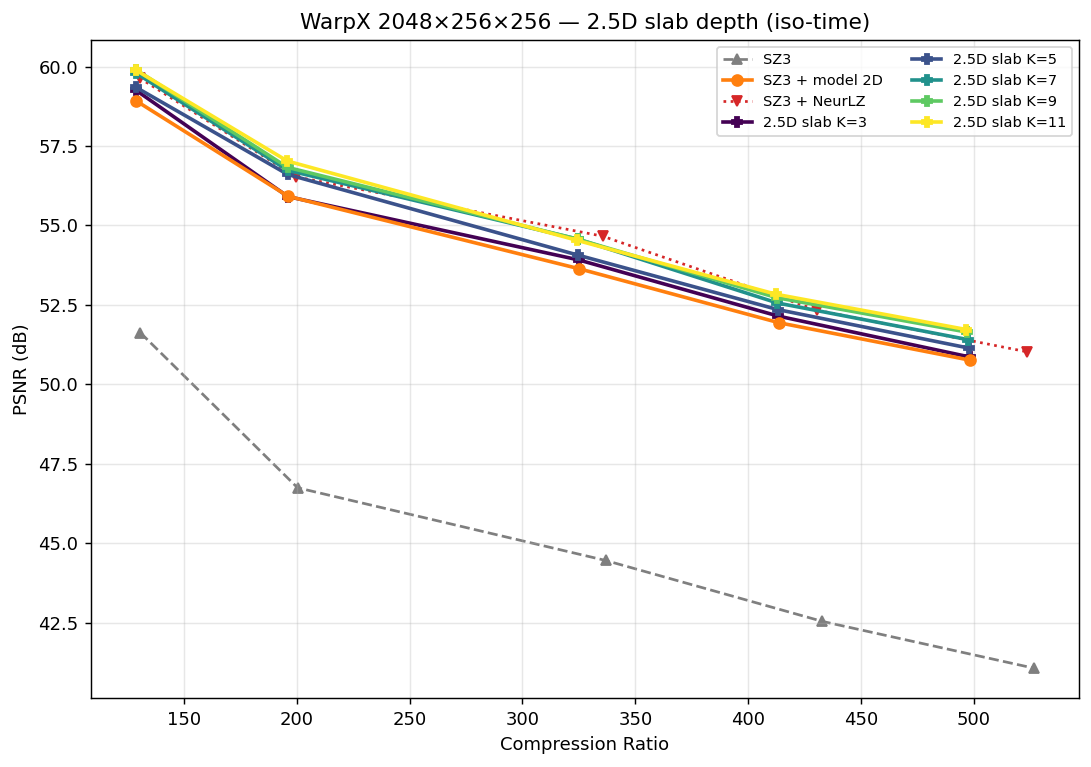

Saved: slab_k_wpx.pdf


In [4]:
# ── WarpX (single field, 20 epochs) — axis 0 = beam-propagation (where slab helps) ──
WPX_RAW       = "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw"
WPX_SRC_SHAPE = (256, 256, 2048)
_wpx = np.fromfile(WPX_RAW, dtype=np.float64).reshape(WPX_SRC_SHAPE).astype(np.float32)
_wpx = np.ascontiguousarray(np.transpose(_wpx, (2, 0, 1)))   # (2048,256,256): axis0=beam (slab stacks here)
WPX_SHAPE = _wpx.shape
WPX_REL   = [1e-2, 2e-2, 3e-2, 4e-2, 5e-2]

set_seed(SEED)
r_wpx = bench_slab_k("wpx", _wpx, [], WPX_SHAPE, WPX_REL, 30000, WPX_TIME)
del _wpx
torch.cuda.empty_cache() if torch.cuda.is_available() else None
fig = plot_slab_k(r_wpx, "WarpX 2048×256×256 — 2.5D slab depth (iso-time)")
plt.savefig("slab_k_wpx.pdf", bbox_inches="tight"); plt.show()
print("Saved: slab_k_wpx.pdf")


## 2. Hurricane CLOUD (100 epochs, +aux)

In [ ]:
# ── Hurricane CLOUD (+6 aux, 100 epochs) ──────────────────────────────────────
HUR_DIR    = "/home/sam/Halo_Finder/halo_finder_v1/100x500x500/"
HUR_SHAPE  = (100, 500, 500)
HUR_TARGET = "CLOUDf48"
HUR_AUX    = ["PRECIPf48", "Pf48", "TCf48", "Uf48", "Vf48", "Wf48"]
HUR_REL    = [1e-3, 2e-3, 3e-3, 4e-3, 6e-3]

tgt = np.fromfile(HUR_DIR + HUR_TARGET + ".bin.f32", dtype=np.float32).reshape(HUR_SHAPE)
aux = [np.memmap(HUR_DIR + a + ".bin.f32", dtype=np.float32, mode="r", shape=HUR_SHAPE) for a in HUR_AUX]
set_seed(SEED)
r_hur = bench_slab_k("Hurricane/CLOUD", tgt, aux, HUR_SHAPE, HUR_REL, 6000, HUR_TIME)
del tgt, aux
torch.cuda.empty_cache() if torch.cuda.is_available() else None
fig = plot_slab_k(r_hur, "Hurricane CLOUD 100×500×500 — 2.5D slab depth (iso-time, +aux)")
plt.savefig("slab_k_hurricane.pdf", bbox_inches="tight"); plt.show()
print("Saved: slab_k_hurricane.pdf")


[Hurricane/CLOUD] budget 6,000 -> bg_h=8 | n_fields=7 | axis0(depth)=100 patch=500 | drange=0.00205 | ISO-TIME budget=80s/model

[Model: spatial] Total Params: 4,876
 [Params] Main (BG) Network : 4,876 parameters
[Init] Epoch   0 | Global PSNR: 72.78 dB | MaxErr: 0.0
[plan] pure_train_budget=80.00s | epochs_cap=100000 | steps/epoch=256 | patch=500 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 7 fields resident on cuda:0 (~1.4 GB)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=3.45s | Loss: 1.542171 | Freq: 1.647986 | Low: 0.187992 | Mid: 0.049976 | High: 0.520060 | Global: 72.81 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈3.549s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=0.75s | Loss: 2.416870 | Freq: 1.541803 | Low: 0.195087 | Mid: 0.052038 | High: 0.561976 | Global: 72.84 dB | MaxErr: 0.0  [New Best!]
Epoch   3 [BG] | train_wall=0.74s | Loss: 2.243951 | Freq: 1.381159 | Low: 0.175129 | Mid: 0.050581 | High: 0.535427 | Global: 73.02 dB | MaxErr: 0.0  [New Best!]
Epoch   4 [BG] | train_wall=0.73s | Loss: 2.013436 | Freq: 1.244706 | Low: 0.145072 | Mid: 0.049874 | High: 0.483151 | Global: 72.72 dB | MaxErr: 0.0
Epoch   5 [BG] | train_wall=0.74s | Loss: 2.079152 | Freq: 1.251170 | Low: 0.126317 | Mid: 0.050411 | High: 0.526968 | Global: 73.72 dB | MaxErr: 0.0  [New Best!]
Epoch   6 [BG] | train_wall=0.73s | Loss: 2.060181 | Freq: 1.216600 | Low: 0.103969 | Mid: 0.048346 | High: 0.551930 

## 3. Magnetic Reconnection (20 epochs)

[Magnetic] budget 30,000 -> bg_h=21 | n_fields=1 | axis0(depth)=512 patch=512 | drange=24.2 | ISO-TIME budget=40s/model

[Model: spatial] Total Params: 28,858
 [Params] Main (BG) Network : 28,858 parameters
[Init] Epoch   0 | Global PSNR: 68.32 dB | MaxErr: 0.0
[plan] pure_train_budget=40.00s | epochs_cap=100000 | steps/epoch=256 | patch=512 | batch=1 | sample=random | data_parallel=False | amp=bf16
[early-stop] DISABLED (cfg.bg_early_stop is False/unset)
[gpu-sampling] 1 fields resident on cuda:0 (~1.1 GB)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=3.06s | Loss: 1.789183 | Freq: 1.457031 | Low: 0.119051 | Mid: 0.039102 | High: 0.718893 | Global: 68.48 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈3.144s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=0.96s | Loss: 2.274641 | Freq: 1.234604 | Low: 0.114450 | Mid: 0.040935 | High: 0.666290 | Global: 68.92 dB | MaxErr: 0.0  [New Best!]
Epoch   3 [BG] | train_wall=0.92s | Loss: 2.116021 | Freq: 1.212494 | Low: 0.095198 | Mid: 0.037873 | High: 0.613637 | Global: 69.01 dB | MaxErr: 0.0  [New Best!]
Epoch   4 [BG] | train_wall=0.93s | Loss: 1.975113 | Freq: 1.205124 | Low: 0.091209 | Mid: 0.034446 | High: 0.552938 | Global: 69.10 dB | MaxErr: 0.0  [New Best!]
Epoch   5 [BG] | train_wall=0.92s | Loss: 2.063200 | Freq: 1.177414 | Low: 0.082678 | Mid: 0.036216 | High: 0.603112 | Global: 69.20 dB | MaxErr: 0.0  [New Best!]
Epoch   6 [BG] | train_wall=0.92s | Loss: 2.077967 | Freq: 1.190491 | Low: 0.076685 | Mid: 0.035508 | Hi

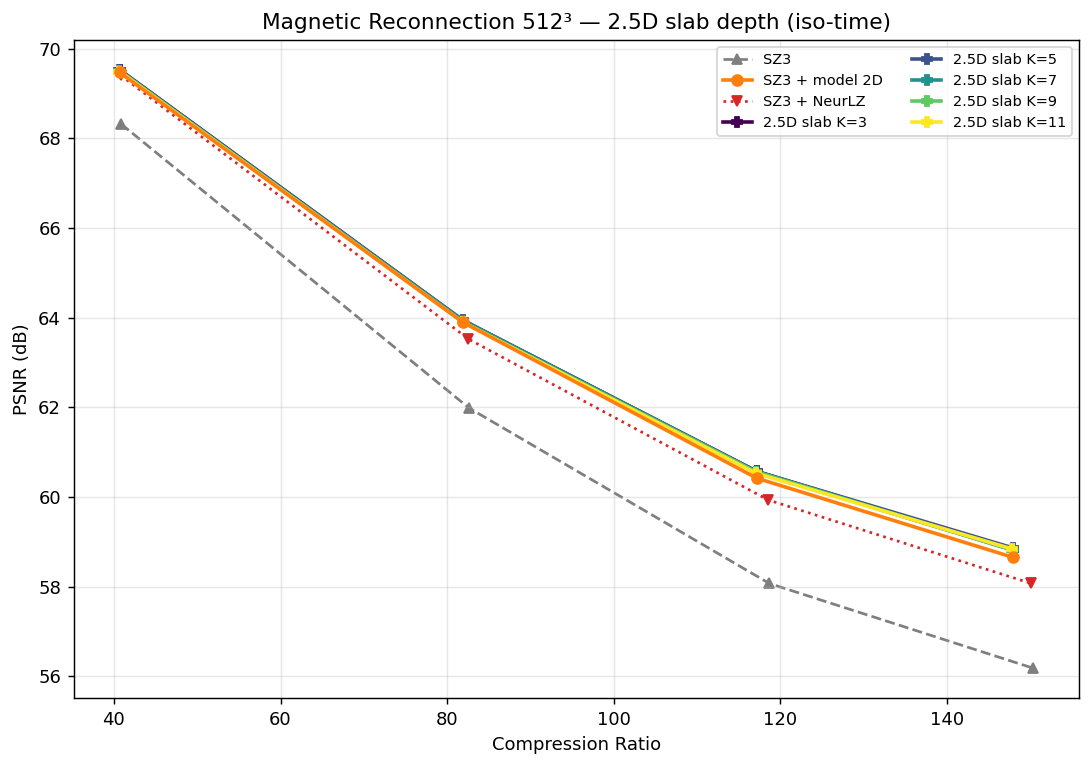

Saved: slab_k_magnetic.pdf


In [4]:
# ── Magnetic Reconnection (single field, 20 epochs) ───────────────────────────
MAG_FILE  = "/home/sam/Halo_Finder/halo_finder_v1/magnetic_reconnection_512x512x512_float32.raw"
MAG_SHAPE = (512, 512, 512)
MAG_REL   = [1e-3, 3e-3, 5e-3, 7e-3]

mag = np.fromfile(MAG_FILE, dtype=np.float32).reshape(MAG_SHAPE)
set_seed(SEED)
r_mag = bench_slab_k("Magnetic", mag, [], MAG_SHAPE, MAG_REL, 30000, MAG_TIME)
del mag
torch.cuda.empty_cache() if torch.cuda.is_available() else None
fig = plot_slab_k(r_mag, "Magnetic Reconnection 512³ — 2.5D slab depth (iso-time)")
plt.savefig("slab_k_magnetic.pdf", bbox_inches="tight"); plt.show()
print("Saved: slab_k_magnetic.pdf")
